1. Thiết lập thư viện và bố cục

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, Wedge
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ─────────────────────────────────────────────────────────────────────────────
# 0. THEME & CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
BG        = "#F8FAFC"   # Background
PANEL     = "#FFFFFF"   # Main cards
PANEL2    = "#F1F5F9"   # Secondary cards
BORDER    = "#CBD5E1"

BLUE      = "#3B82F6"
GREEN     = "#10B981"
RED       = "#EF4444"
ORANGE    = "#F59E0B"
PURPLE    = "#8B5CF6"
YELLOW    = "#EAB308"
TEAL      = "#14B8A6"

TEXT      = "#0F172A"
SUBTEXT   = "#64748B"
GRID      = "#E2E8F0"

PALETTE   = [
    BLUE, GREEN, ORANGE, PURPLE, RED,
    YELLOW, TEAL,
    "#EC4899",  # Pink
    "#84CC16",  # Lime
    "#06B6D4"   # Cyan
]

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL,
    "axes.edgecolor":     BORDER,
    "axes.labelcolor":    TEXT,
    "axes.titlecolor":    TEXT,
    "xtick.color":        SUBTEXT,
    "ytick.color":        SUBTEXT,
    "text.color":         TEXT,
    "grid.color":         GRID,
    "grid.linewidth":     0.6,
    "font.family":        "DejaVu Sans",
    "legend.facecolor":   PANEL2,
    "legend.edgecolor":   BORDER,
})


2. Tải dữ liệu và lọc dữ liệu cần phân tích

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD & FILTER DATASETS
# ─────────────────────────────────────────────────────────────────────────────
desires = pd.read_csv("domain_worker_desires.csv")
metadata = pd.read_csv("domain_worker_metadata.csv")
expert   = pd.read_csv("expert_rated_technological_capability.csv")
tasks    = pd.read_csv("task_statement_with_metadata.csv")

# Filtering
CS_KW = ["Computer", "Software", "Information", "Data", "Network", "Web",
         "Database", "System", "Technology", "Developer", "Programmer",
         "Analyst", "Engineer", "IT Project", "Business Intelligence",
         "Cybersecurity", "Database"]

def is_cs(occ):
    if pd.isna(occ): return False
    return any(k.lower() in str(occ).lower() for k in CS_KW)

cs_desires = desires[desires["Occupation (O*NET-SOC Title)"].apply(is_cs)].copy()
cs_expert  = expert[expert["Occupation (O*NET-SOC Title)"].apply(is_cs)].copy()
cs_meta    = metadata[metadata["Occupation (O*NET-SOC Title)"].apply(is_cs)].copy()
cs_tasks   = tasks[tasks["Occupation (O*NET-SOC Title)"].apply(is_cs)].copy()

# Short occupation labels
SHORT = {
    "Web Developers": "Web Devs",
    "Computer Programmers": "Programmers",
    "Computer and Information Systems Managers": "IS Managers",
    "Computer Systems Analysts": "Sys Analysts",
    "Software Quality Assurance Analysts and Testers": "QA/Testers",
    "Information Technology Project Managers": "IT PM",
    "Network and Computer Systems Administrators": "Net/SysAdmin",
    "Computer Systems Engineers/Architects": "Sys Engineers",
    "Computer User Support Specialists": "Support Spec.",
    "Web Administrators": "Web Admins",
    "Computer and Information Research Scientists": "CS Researchers",
    "Business Intelligence Analysts": "BI Analysts",
    "Database Administrators": "DBA",
    "Information Security Analysts": "InfoSec",
    "Data Entry Keyers": "Data Entry",
    "Logistic Analysts": "Logistics",
    "Management Analysts": "Mgmt Analysts",
    "Quality Control Systems Managers": "QC Mgrs",
}

def shorten(name):
    return SHORT.get(name, name.split(" and ")[0].split(",")[0].strip()[:22])

# ─────────────────────────────────────────────────────────────────────────────
# HELPER
# ─────────────────────────────────────────────────────────────────────────────
def title_box(ax, fig, title, subtitle=""):
    ax.text(0.01, 1.04, title, transform=ax.transAxes,
            fontsize=12, fontweight="bold", color=TEXT, va="bottom")
    if subtitle:
        ax.text(0.01, 1.00, subtitle, transform=ax.transAxes,
                fontsize=8.5, color=SUBTEXT, va="bottom")

def fig_suptitle(fig, title, subtitle=""):
    fig.text(0.5, 0.985, title, ha="center", va="top",
             fontsize=17, fontweight="bold", color=TEXT)
    if subtitle:
        fig.text(0.5, 0.965, subtitle, ha="center", va="top",
                 fontsize=10, color=SUBTEXT)

def gradient_bar(ax, x_vals, y_labels, cmap_name="Blues", vmin=1, vmax=5,
                 label_color=TEXT):
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    for i, (v, lbl) in enumerate(zip(x_vals, y_labels)):
        color = cmap(norm(v))
        bar = ax.barh(i, v, color=color, height=0.65,
                      edgecolor=BORDER, linewidth=0.4)
        ax.text(v + 0.05, i, f"{v:.2f}", va="center",
                fontsize=8, color=TEXT, fontweight="bold")
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=9, color=label_color)
    ax.set_xlim(0, vmax + 0.5)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)


Rendering Figure 1 …
  ✓ Fig 1 saved


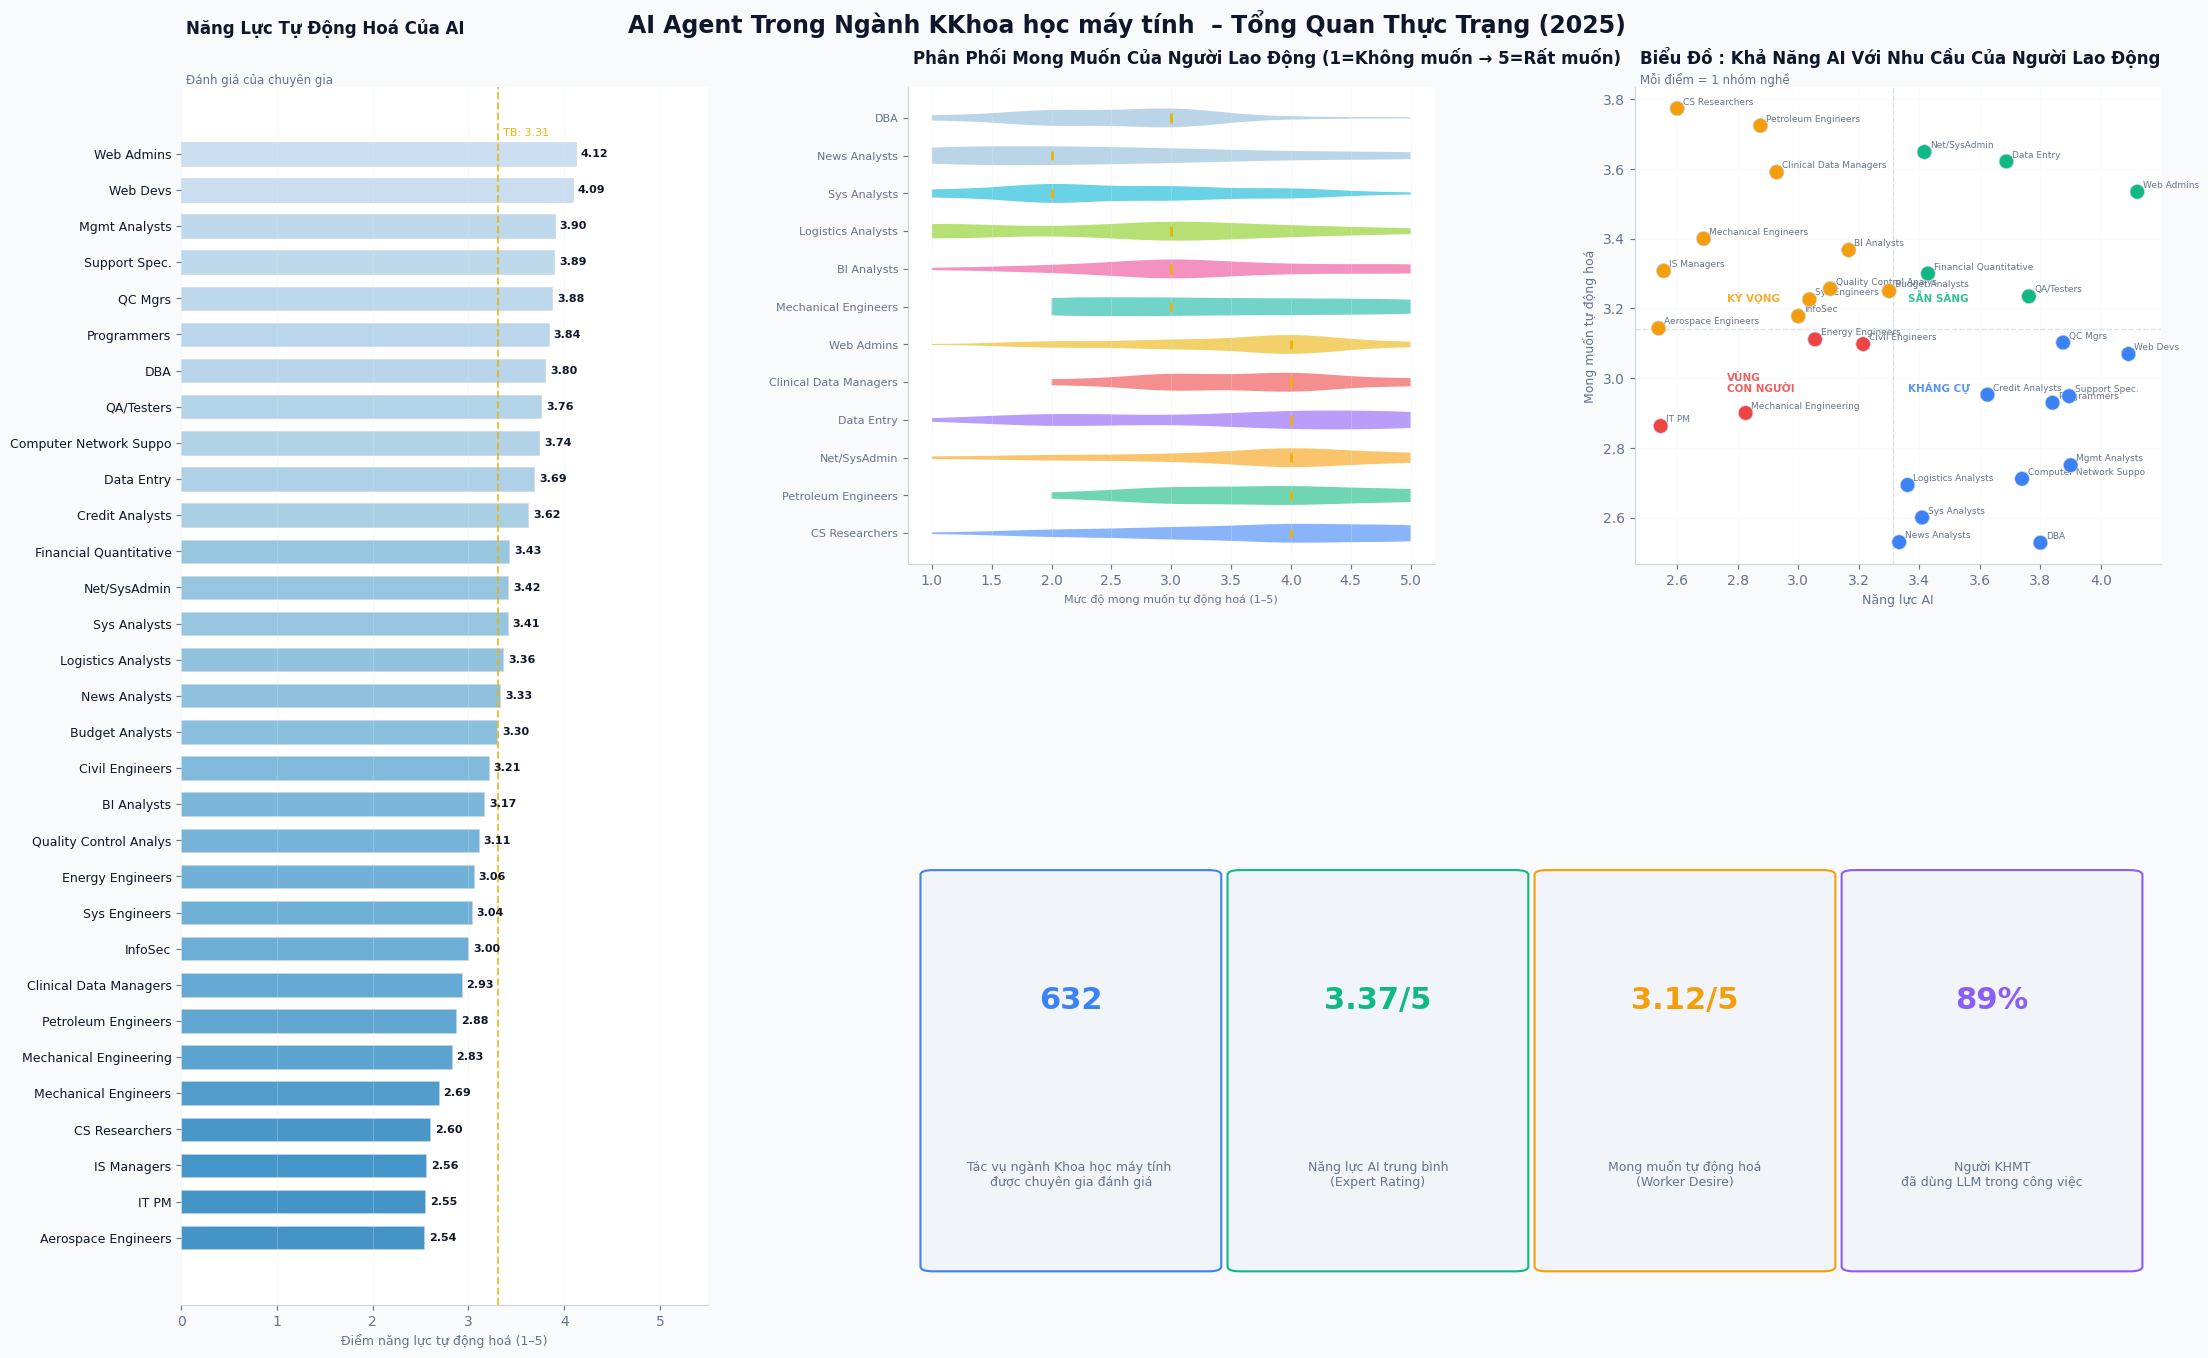

In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1: TỔNG QUAN THỰC TRẠNG AI TRONG LĨNH VỰC KHOA HỌC MÁY TÍNH
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 1 …")

# --- aggregate per occupation
occ_exp = (cs_expert.groupby("Occupation (O*NET-SOC Title)")["Automation Capacity Rating"]
           .agg(["mean", "count"]).reset_index()
           .sort_values("mean", ascending=True))
occ_exp["short"] = occ_exp["Occupation (O*NET-SOC Title)"].apply(shorten)

occ_des = (cs_desires.groupby("Occupation (O*NET-SOC Title)")["Automation Desire Rating"]
           .agg(["mean", "count"]).reset_index()
           .sort_values("mean", ascending=True))
occ_des["short"] = occ_des["Occupation (O*NET-SOC Title)"].apply(shorten)

# scatter data (merge on occ name)
scatter_df = occ_exp.rename(columns={"mean": "expert_mean"}).merge(
    occ_des.rename(columns={"mean": "desire_mean"}),
    on="Occupation (O*NET-SOC Title)"
)
scatter_df["occ_label"] = scatter_df["Occupation (O*NET-SOC Title)"].apply(shorten)

fig1 = plt.figure(figsize=(22, 14), facecolor=BG)
fig1.patch.set_facecolor(BG)
fig_suptitle(fig1,
    "AI Agent Trong Ngành KKhoa học máy tính  – Tổng Quan Thực Trạng (2025)")

gs = GridSpec(2, 3, figure=fig1, hspace=0.55, wspace=0.38,
              left=0.07, right=0.97, top=0.93, bottom=0.06)

# 1-A  Expert Automation Capacity
ax1a = fig1.add_subplot(gs[:, 0])
vals_e = occ_exp["mean"].values
lbls_e = occ_exp["short"].values
gradient_bar(ax1a, vals_e, lbls_e, "Blues_r")
ax1a.axvline(vals_e.mean(), color=YELLOW, lw=1.4, ls="--", alpha=0.8)
ax1a.text(vals_e.mean() + 0.05, len(lbls_e) - 0.5,
          f"TB: {vals_e.mean():.2f}", color=YELLOW, fontsize=8)
ax1a.set_xlabel("Điểm năng lực tự động hoá (1–5)", fontsize=9, color=SUBTEXT)
ax1a.set_facecolor(PANEL)
title_box(ax1a, fig1,
    "Năng Lực Tự Động Hoá Của AI",
    "Đánh giá của chuyên gia")

# 1-B  Worker Automation Desire Distribution (violin)
ax1b = fig1.add_subplot(gs[0, 1])
top_occ = (cs_desires.groupby("Occupation (O*NET-SOC Title)")["Automation Desire Rating"]
           .mean().nlargest(8).index.tolist()
           + cs_desires.groupby("Occupation (O*NET-SOC Title)")["Automation Desire Rating"]
           .mean().nsmallest(4).index.tolist())
sub_des = cs_desires[cs_desires["Occupation (O*NET-SOC Title)"].isin(top_occ)].copy()
sub_des["short"] = sub_des["Occupation (O*NET-SOC Title)"].apply(shorten)
order_b = (sub_des.groupby("short")["Automation Desire Rating"]
           .mean().sort_values(ascending=False).index)
vp = ax1b.violinplot(
    [sub_des.loc[sub_des["short"] == o, "Automation Desire Rating"].dropna().values
     for o in order_b],
    vert=False, showmedians=True, showextrema=False
)
for i, (body, color) in enumerate(zip(vp["bodies"], PALETTE)):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color(YELLOW)
vp["cmedians"].set_linewidth(2)
ax1b.set_yticks(range(1, len(order_b) + 1))
ax1b.set_yticklabels(list(order_b), fontsize=8)
ax1b.set_xlabel("Mức độ mong muốn tự động hoá (1–5)", fontsize=8, color=SUBTEXT)
ax1b.set_facecolor(PANEL)
ax1b.spines[["top","right"]].set_visible(False)
ax1b.grid(axis="x", alpha=0.3)
title_box(ax1b, fig1,
    "Phân Phối Mong Muốn Của Người Lao Động (1=Không muốn → 5=Rất muốn)")

# 1-C  Quadrant scatter (Expert vs Worker)
ax1c = fig1.add_subplot(gs[0, 2])
exp_mean = scatter_df["expert_mean"].mean()
des_mean = scatter_df["desire_mean"].mean()

colors_q = []
for _, row in scatter_df.iterrows():
    if row.expert_mean >= exp_mean and row.desire_mean >= des_mean:
        colors_q.append(GREEN)
    elif row.expert_mean < exp_mean and row.desire_mean >= des_mean:
        colors_q.append(ORANGE)
    elif row.expert_mean >= exp_mean and row.desire_mean < des_mean:
        colors_q.append(BLUE)
    else:
        colors_q.append(RED)

sc = ax1c.scatter(scatter_df["expert_mean"], scatter_df["desire_mean"],
                  c=colors_q, s=110, edgecolors=BORDER, linewidths=0.5, zorder=5)
for _, row in scatter_df.iterrows():
    lbl = row["occ_label"]
    ax1c.annotate(lbl, (row.expert_mean, row.desire_mean),
                  textcoords="offset points", xytext=(4, 3),
                  fontsize=6.5, color=SUBTEXT)
ax1c.axvline(exp_mean, color=BORDER, lw=1, ls="--", alpha=0.7)
ax1c.axhline(des_mean, color=BORDER, lw=1, ls="--", alpha=0.7)
quad_labels = [
    (exp_mean + 0.05, des_mean + 0.08, "SẴN SÀNG", GREEN),
    (exp_mean - 0.55, des_mean + 0.08, "KỲ VỌNG", ORANGE),
    (exp_mean + 0.05, des_mean - 0.18, "KHÁNG CỰ", BLUE),
    (exp_mean - 0.55, des_mean - 0.18, "VÙNG\nCON NGƯỜI", RED),
]
for xx, yy, lbl, col in quad_labels:
    ax1c.text(xx, yy, lbl, fontsize=7.5, color=col, fontweight="bold", alpha=0.85)
ax1c.set_xlabel("Năng lực AI", fontsize=9, color=SUBTEXT)
ax1c.set_ylabel("Mong muốn tự động hoá", fontsize=9, color=SUBTEXT)
ax1c.set_facecolor(PANEL)
ax1c.spines[["top","right"]].set_visible(False)
ax1c.grid(alpha=0.25)
title_box(ax1c, fig1,
    "Biểu Đồ : Khả Năng AI Với Nhu Cầu Của Người Lao Động",
    "Mỗi điểm = 1 nhóm nghề ")

# 1-D  4 KPI stat cards
ax1d = fig1.add_subplot(gs[1, 1:])
ax1d.set_facecolor(BG)
ax1d.axis("off")

kpis = [
    ("632", "Tác vụ ngành Khoa học máy tính \nđược chuyên gia đánh giá", BLUE),
    (f"{cs_expert['Automation Capacity Rating'].mean():.2f}/5",
     "Năng lực AI trung bình\n(Expert Rating)", GREEN),
    (f"{cs_desires['Automation Desire Rating'].mean():.2f}/5",
     "Mong muốn tự động hoá\n(Worker Desire)", ORANGE),
    (f"{(cs_meta['LLM Use in Work'].str.contains('Yes', na=False)).mean()*100:.0f}%",
     "Người KHMT\nđã dùng LLM trong công việc", PURPLE),
]
for i, (val, lbl, col) in enumerate(kpis):
    x0 = 0.02 + i * 0.245
    rect = FancyBboxPatch((x0, 0.08), 0.22, 0.82,
                          boxstyle="round,pad=0.01",
                          linewidth=1.5, edgecolor=col,
                          facecolor=PANEL2,
                          transform=ax1d.transAxes, clip_on=False, zorder=2)
    ax1d.add_patch(rect)
    ax1d.text(x0 + 0.11, 0.62, val,
              transform=ax1d.transAxes, ha="center",
              fontsize=22, fontweight="bold", color=col, zorder=3)
    ax1d.text(x0 + 0.11, 0.25, lbl,
              transform=ax1d.transAxes, ha="center",
              fontsize=9, color=SUBTEXT, zorder=3,
              multialignment="center")

fig1.savefig("fig1_overview.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 1 saved")
plt.show(fig1)



Rendering Figure 2 …
  ✓ Fig 2 saved


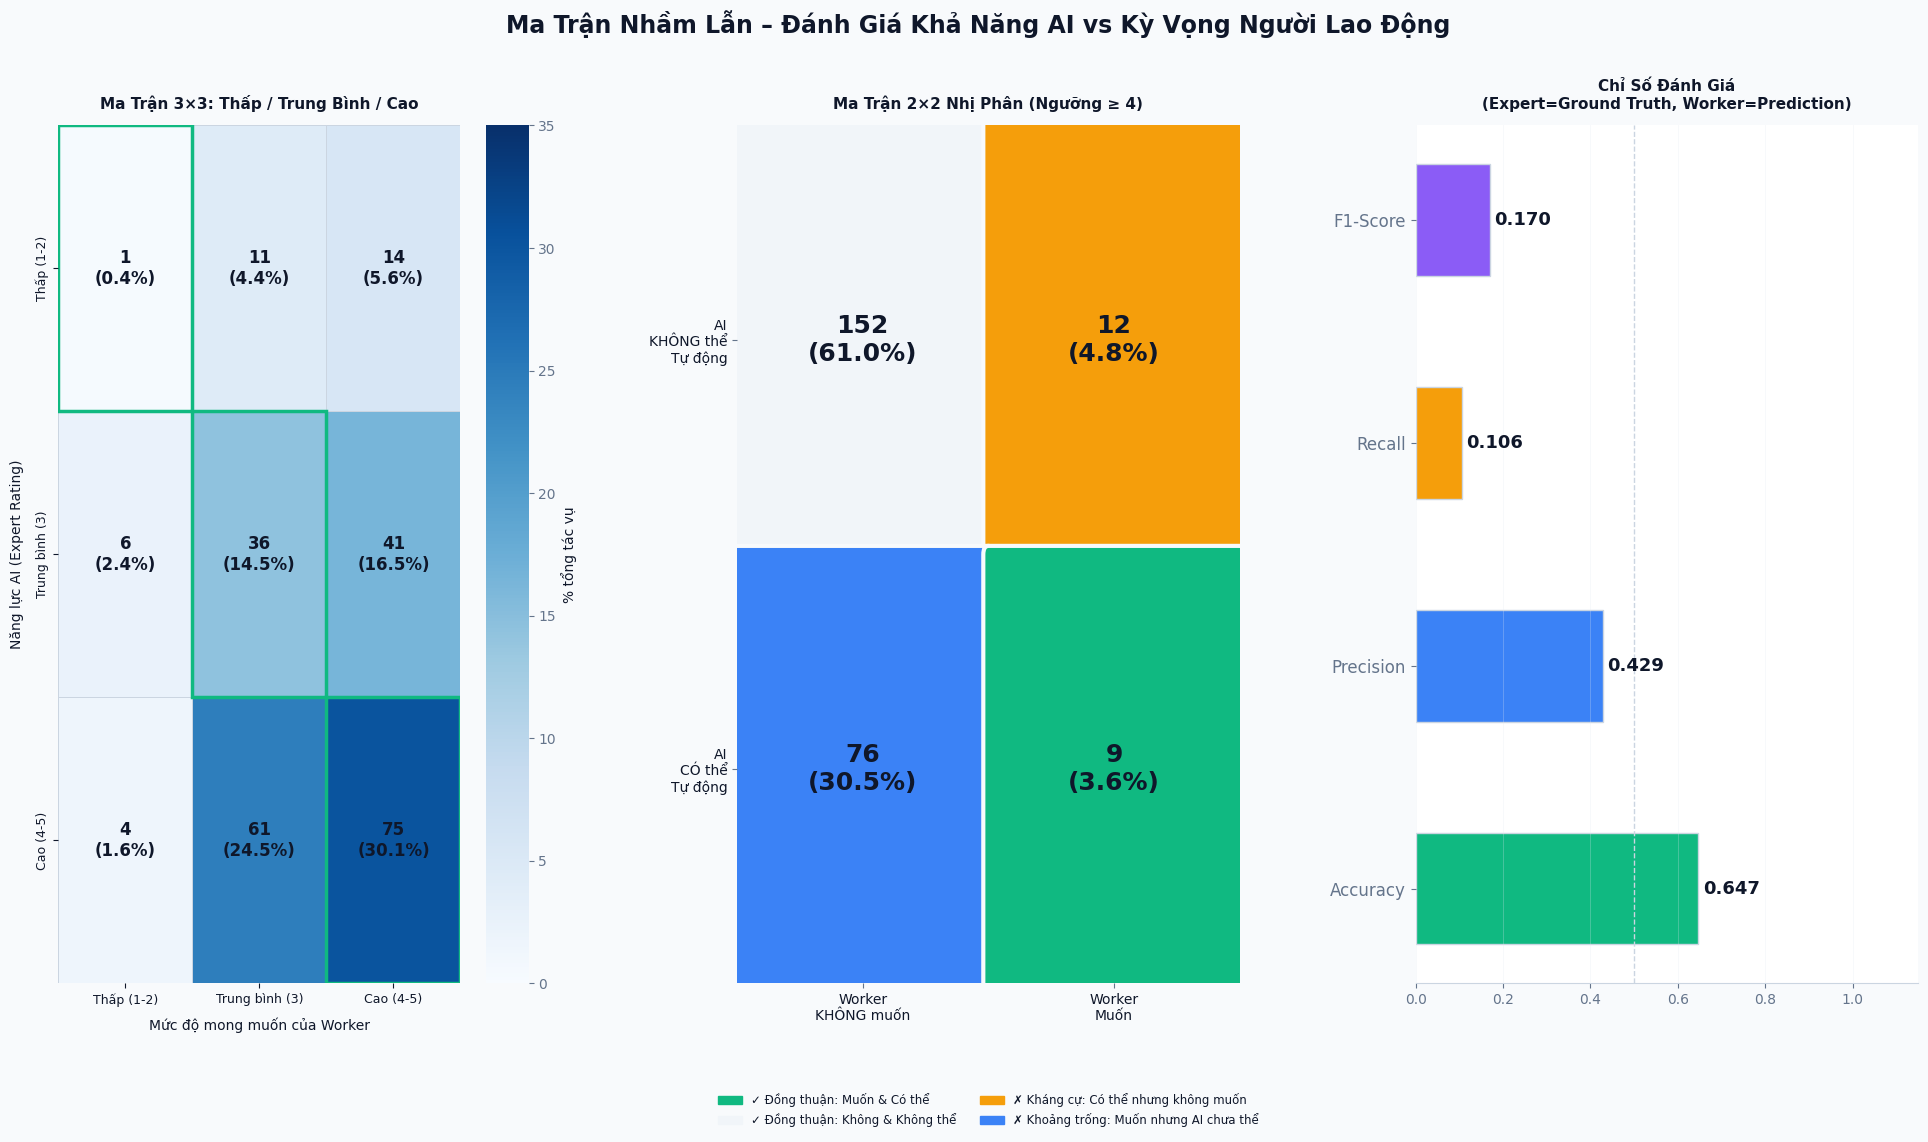

In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2: MA TRẬN NHẦM LẪN – EXPERT vs WORKER
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 2 …")

# Merge on Task ID
exp_agg = cs_expert.groupby("Task ID")["Automation Capacity Rating"].mean().reset_index()
wkr_agg = cs_desires.groupby("Task ID")["Automation Desire Rating"].mean().reset_index()
cm_df = exp_agg.merge(wkr_agg, on="Task ID")
cm_df.columns = ["Task ID", "Expert_Cap", "Worker_Des"]

def tri_label(x):
    if x <= 2: return "Thấp (1-2)"
    elif x <= 3: return "Trung bình (3)"
    else: return "Cao (4-5)"

cm_df["E_cat"] = cm_df["Expert_Cap"].apply(tri_label)
cm_df["W_cat"] = cm_df["Worker_Des"].apply(tri_label)
ORDER = ["Thấp (1-2)", "Trung bình (3)", "Cao (4-5)"]

# 3×3 confusion matrix (Expert=rows, Worker=cols)
conf = pd.crosstab(cm_df["E_cat"], cm_df["W_cat"])
conf = conf.reindex(index=ORDER, columns=ORDER, fill_value=0)
conf_pct = conf.div(conf.values.sum()) * 100

# Binary 2×2: ≥4 → "Automatable"
cm_df["E_bin"] = (cm_df["Expert_Cap"] >= 4).astype(int)
cm_df["W_bin"] = (cm_df["Worker_Des"] >= 4).astype(int)
bin_cm = confusion_matrix(cm_df["E_bin"], cm_df["W_bin"])
bin_cm_df = pd.DataFrame(
    bin_cm,
    index=["Expert: Không thể (< 4)", "Expert: Có thể tự động (≥ 4)"],
    columns=["Worker: Không muốn (< 4)", "Worker: Muốn (≥ 4)"]
)

# --- accuracy metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc  = accuracy_score(cm_df["E_bin"], cm_df["W_bin"])
prec = precision_score(cm_df["E_bin"], cm_df["W_bin"])
rec  = recall_score(cm_df["E_bin"], cm_df["W_bin"])
f1   = f1_score(cm_df["E_bin"], cm_df["W_bin"])

fig2 = plt.figure(figsize=(20, 11), facecolor=BG)
fig_suptitle(fig2,
    "Ma Trận Nhầm Lẫn – Đánh Giá Khả Năng AI vs Kỳ Vọng Người Lao Động")
gs2 = GridSpec(1, 3, figure=fig2, wspace=0.35,
               left=0.04, right=0.97, top=0.88, bottom=0.10)

# 2-A  3×3 heatmap
ax2a = fig2.add_subplot(gs2[0, 0])
annot_3x3 = np.array([[f"{conf.values[r,c]}\n({conf_pct.values[r,c]:.1f}%)"
                        for c in range(3)] for r in range(3)])
sns.heatmap(conf_pct, ax=ax2a, cmap="Blues", linewidths=0.5,
            linecolor=BORDER, annot=annot_3x3, fmt="",
            annot_kws={"size": 12, "color": TEXT, "weight": "bold"},
            cbar_kws={"label": "% tổng tác vụ"},
            vmin=0, vmax=35)
ax2a.set_xlabel("Mức độ mong muốn của Worker", fontsize=10, color=TEXT, labelpad=8)
ax2a.set_ylabel("Năng lực AI (Expert Rating)", fontsize=10, color=TEXT, labelpad=8)
ax2a.tick_params(axis="both", labelsize=9, colors=TEXT)
ax2a.set_facecolor(PANEL)
ax2a.set_title("Ma Trận 3×3: Thấp / Trung Bình / Cao", color=TEXT,
               fontsize=11, fontweight="bold", pad=12)

# Highlight diagonal
for i in range(3):
    ax2a.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                 edgecolor=GREEN, lw=2.5))

# 2-B  2×2 binary
ax2b = fig2.add_subplot(gs2[0, 1])
CELL_COLORS = [[PANEL2, ORANGE], [BLUE, GREEN]]
for r in range(2):
    for c in range(2):
        ax2b.add_patch(FancyBboxPatch((c, 1-r), 1, 1,
                                     boxstyle="round,pad=0.02",
                                     facecolor=CELL_COLORS[r][c],
                                     edgecolor=BG, linewidth=3))
        v = bin_cm[r][c]
        pct = v / bin_cm.sum() * 100
        ax2b.text(c + 0.5, 1.5 - r, f"{v}\n({pct:.1f}%)",
                  ha="center", va="center",
                  fontsize=18, fontweight="bold", color=TEXT)

labels_r = ["AI\nKHÔNG thể\nTự động", "AI\nCÓ thể\nTự động"]
labels_c = ["Worker\nKHÔNG muốn", "Worker\nMuốn"]
ax2b.set_xticks([0.5, 1.5]);  ax2b.set_xticklabels(labels_c, fontsize=10, color=TEXT)
ax2b.set_yticks([0.5, 1.5]);  ax2b.set_yticklabels(labels_r[::-1], fontsize=10, color=TEXT)
ax2b.set_xlim(0, 2);  ax2b.set_ylim(0, 2)
ax2b.spines[:].set_visible(False)
ax2b.set_facecolor(BG)

# legend for colors
legend_patches = [
    mpatches.Patch(color=GREEN,  label="✓ Đồng thuận: Muốn & Có thể"),
    mpatches.Patch(color=PANEL2, label="✓ Đồng thuận: Không & Không thể"),
    mpatches.Patch(color=ORANGE, label="✗ Kháng cự: Có thể nhưng không muốn"),
    mpatches.Patch(color=BLUE,   label="✗ Khoảng trống: Muốn nhưng AI chưa thể"),
]
ax2b.legend(handles=legend_patches, loc="lower center",
            bbox_to_anchor=(0.5, -0.18), fontsize=8.5,
            framealpha=0.0, ncol=2, labelcolor=TEXT)
ax2b.set_title("Ma Trận 2×2 Nhị Phân (Ngưỡng ≥ 4)", color=TEXT,
               fontsize=11, fontweight="bold", pad=12)

# 2-C  Metrics bar
ax2c = fig2.add_subplot(gs2[0, 2])
ax2c.set_facecolor(PANEL)
metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
m_colors = [GREEN, BLUE, ORANGE, PURPLE]
bars = ax2c.barh(list(metrics.keys()), list(metrics.values()),
                 color=m_colors, height=0.5, edgecolor=BORDER)
for bar, v in zip(bars, metrics.values()):
    ax2c.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
              f"{v:.3f}", va="center", fontsize=13,
              fontweight="bold", color=TEXT)
ax2c.set_xlim(0, 1.15)
ax2c.axvline(0.5, color=BORDER, lw=1, ls="--")
ax2c.spines[["top","right","left"]].set_visible(False)
ax2c.tick_params(axis="y", labelsize=12)
ax2c.grid(axis="x", alpha=0.3)
ax2c.set_title("Chỉ Số Đánh Giá\n(Expert=Ground Truth, Worker=Prediction)",
               color=TEXT, fontsize=11, fontweight="bold", pad=12)


fig2.savefig("fig2_confusion_matrix.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 2 saved")
plt.show(fig2)




Rendering Figure 3 …
  ✓ Fig 3 saved


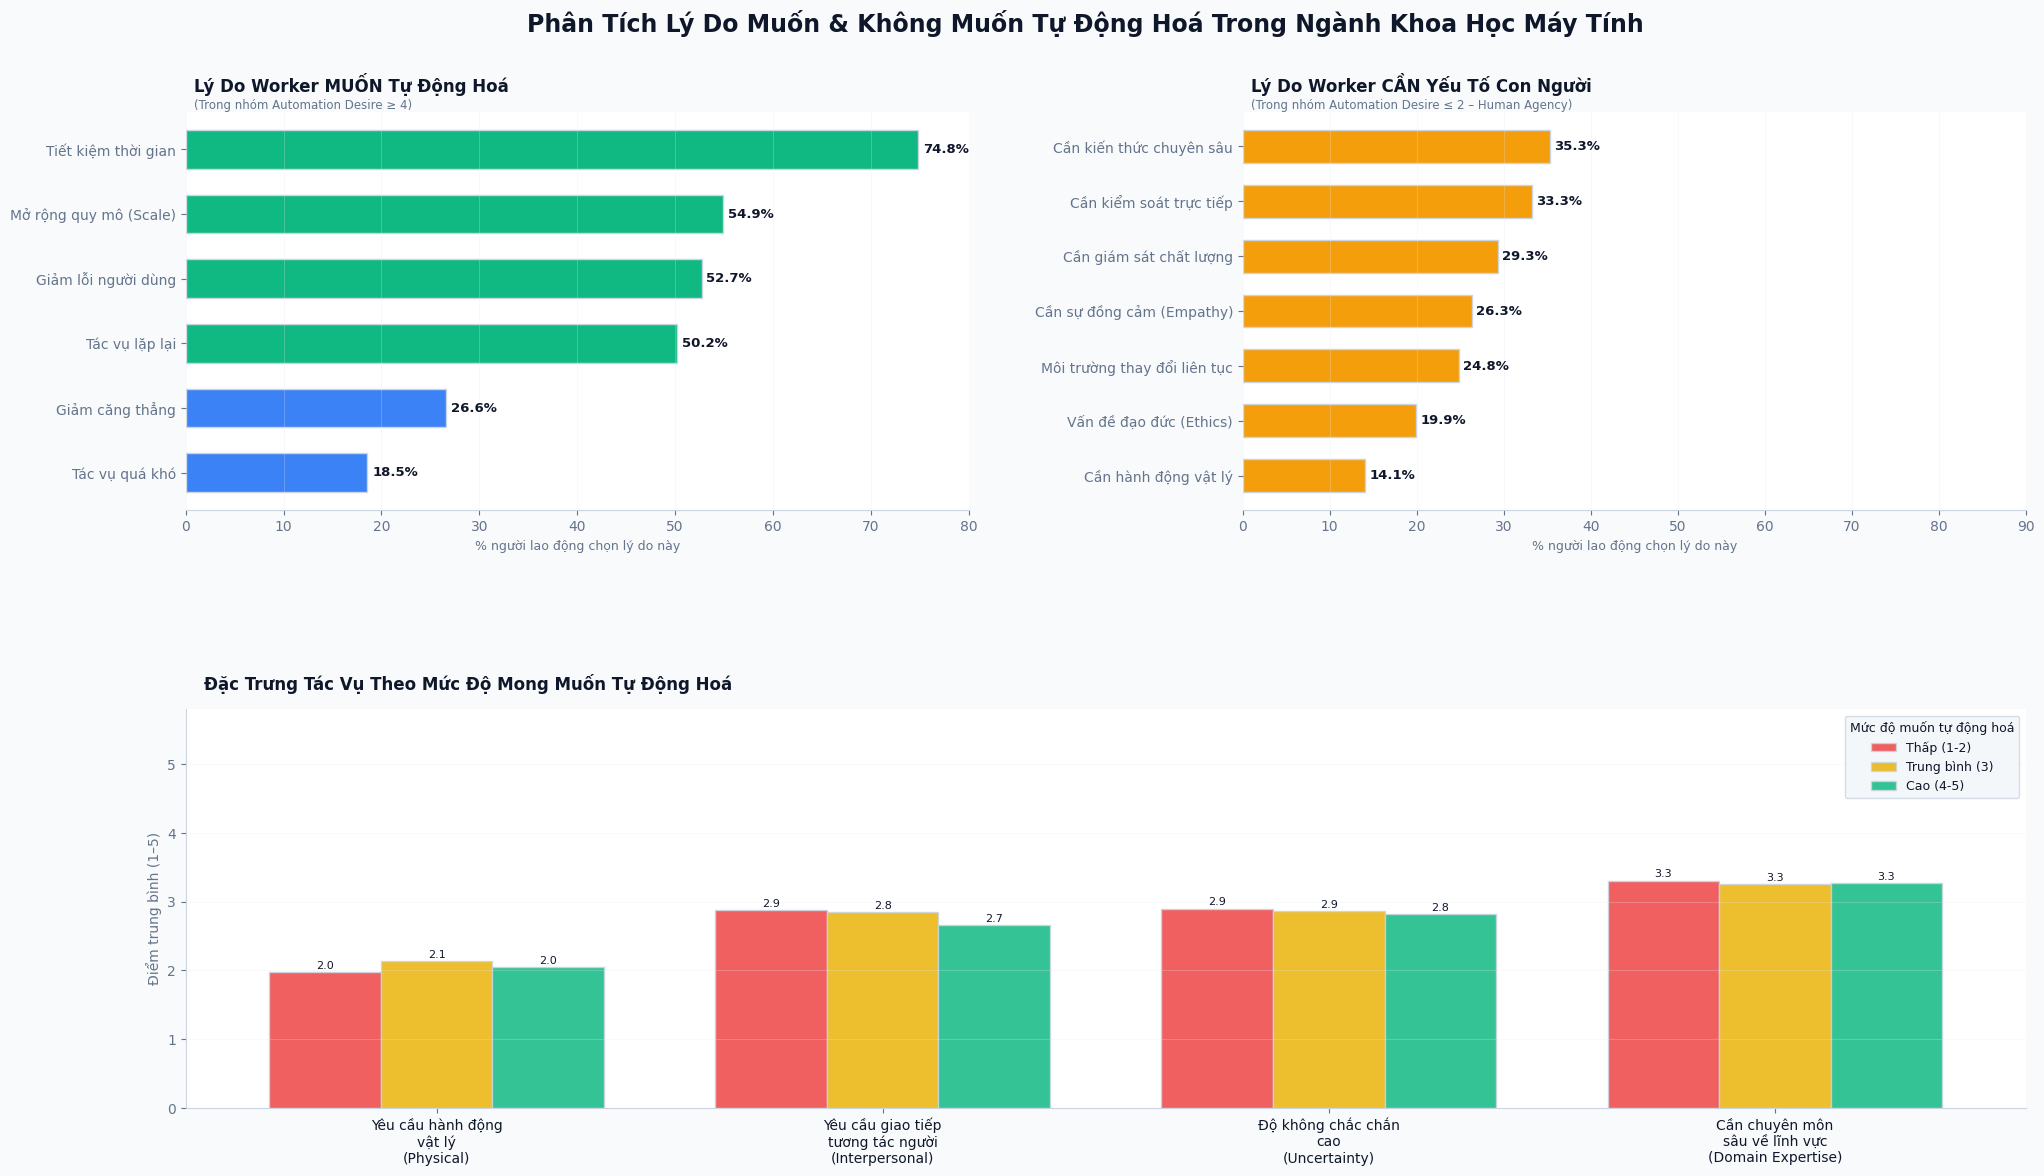

In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3: LÝ DO MUỐN / KHÔNG MUỐN TỰ ĐỘNG HOÁ
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 3 …")

reason_auto_cols = {
    "Tiết kiệm thời gian":     "Reasons for Automation Desire - Free Time",
    "Tác vụ lặp lại":          "Reasons for Automation Desire - Repetitive",
    "Giảm lỗi người dùng":     "Reasons for Automation Desire - Human Error",
    "Giảm căng thẳng":         "Reasons for Automation Desire - Stress",
    "Tác vụ quá khó":          "Reasons for Automation Desire - Difficulty",
    "Mở rộng quy mô (Scale)":  "Reasons for Automation Desire - Scale",
}
reason_agency_cols = {
    "Cần hành động vật lý":      "Reasons for Human Agency - Physical",
    "Cần kiểm soát trực tiếp":   "Reasons for Human Agency - Control",
    "Cần kiến thức chuyên sâu":  "Reasons for Human Agency - Domain Knowledge",
    "Cần sự đồng cảm (Empathy)": "Reasons for Human Agency - Empathy",
    "Cần giám sát chất lượng":   "Reasons for Human Agency - Quality Oversight",
    "Môi trường thay đổi liên tục":"Reasons for Human Agency - Dynamic",
    "Vấn đề đạo đức (Ethics)":   "Reasons for Human Agency - Ethical",
}

# --- convert bool cols safely
for col in list(reason_auto_cols.values()) + list(reason_agency_cols.values()):
    cs_desires[col] = cs_desires[col].map({"True": True, "False": False, True: True, False: False})

# % True for CS workers
auto_pct = {}
for label, col in reason_auto_cols.items():
    s = cs_desires.loc[cs_desires["Automation Desire Rating"] >= 4, col]
    auto_pct[label] = s.mean() * 100 if len(s) > 0 else 0

agency_pct = {}
for label, col in reason_agency_cols.items():
    s = cs_desires.loc[cs_desires["Automation Desire Rating"] <= 2, col]
    agency_pct[label] = s.mean() * 100 if len(s) > 0 else 0

# Difference in automation desire: highly skilled vs low skill tasks
task_chars = ["Physical Action Requirement", "Interpersonal Communication Requirement",
              "Involved Uncertainty", "Domain Expertise Requirement"]
cs_desires["auto_level"] = pd.cut(cs_desires["Automation Desire Rating"],
                                   bins=[0, 2, 3, 5],
                                   labels=["Thấp (1-2)", "Trung bình (3)", "Cao (4-5)"])
char_means = cs_desires.groupby("auto_level", observed=True)[task_chars].mean()

fig3 = plt.figure(figsize=(20, 12), facecolor=BG)
fig_suptitle(fig3,
    "Phân Tích Lý Do Muốn & Không Muốn Tự Động Hoá Trong Ngành Khoa Học Máy Tính")
gs3 = GridSpec(2, 2, figure=fig3, hspace=0.5, wspace=0.35,
               left=0.05, right=0.97, top=0.90, bottom=0.07)

# 3-A  Reasons FOR automation (among high-desire workers)
ax3a = fig3.add_subplot(gs3[0, 0])
lbls_a = list(auto_pct.keys())
vals_a = list(auto_pct.values())
idx_a  = np.argsort(vals_a)
colors_a = [GREEN if v >= 35 else BLUE for v in np.array(vals_a)[idx_a]]
bars_a = ax3a.barh([lbls_a[i] for i in idx_a],
                   [vals_a[i] for i in idx_a],
                   color=colors_a, height=0.6, edgecolor=BORDER)
for bar, v in zip(bars_a, [vals_a[i] for i in idx_a]):
    ax3a.text(v + 0.5, bar.get_y() + bar.get_height()/2,
              f"{v:.1f}%", va="center", fontsize=9.5,
              color=TEXT, fontweight="bold")
ax3a.set_xlim(0, 80)
ax3a.spines[["top","right","left"]].set_visible(False)
ax3a.grid(axis="x", alpha=0.3)
ax3a.set_facecolor(PANEL)
ax3a.set_xlabel("% người lao động chọn lý do này", fontsize=9, color=SUBTEXT)
title_box(ax3a, fig3,
    "Lý Do Worker MUỐN Tự Động Hoá",
    "(Trong nhóm Automation Desire ≥ 4)")

# 3-B  Reasons AGAINST automation (human agency)
ax3b = fig3.add_subplot(gs3[0, 1])
lbls_b = list(agency_pct.keys())
vals_b = list(agency_pct.values())
idx_b  = np.argsort(vals_b)
colors_b = [RED if v >= 50 else ORANGE for v in np.array(vals_b)[idx_b]]
bars_b = ax3b.barh([lbls_b[i] for i in idx_b],
                   [vals_b[i] for i in idx_b],
                   color=colors_b, height=0.6, edgecolor=BORDER)
for bar, v in zip(bars_b, [vals_b[i] for i in idx_b]):
    ax3b.text(v + 0.5, bar.get_y() + bar.get_height()/2,
              f"{v:.1f}%", va="center", fontsize=9.5,
              color=TEXT, fontweight="bold")
ax3b.set_xlim(0, 90)
ax3b.spines[["top","right","left"]].set_visible(False)
ax3b.grid(axis="x", alpha=0.3)
ax3b.set_facecolor(PANEL)
ax3b.set_xlabel("% người lao động chọn lý do này", fontsize=9, color=SUBTEXT)
title_box(ax3b, fig3,
    "Lý Do Worker CẦN Yếu Tố Con Người",
    "(Trong nhóm Automation Desire ≤ 2 – Human Agency)")

# 3-C  Task characteristics by automation level (grouped bar)
ax3c = fig3.add_subplot(gs3[1, :])
x = np.arange(len(task_chars))
levels = char_means.index.tolist()
width = 0.25
clr_map = [RED, YELLOW, GREEN]
for j, (lvl, col) in enumerate(zip(levels, clr_map)):
    bars_c = ax3c.bar(x + (j - 1) * width, char_means.loc[lvl].values,
                      width=width, color=col, alpha=0.85,
                      edgecolor=BORDER, label=lvl)
    for bar in bars_c:
        h = bar.get_height()
        if h > 0:
            ax3c.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                      f"{h:.1f}", ha="center", fontsize=8,
                      color=TEXT)
ax3c.set_xticks(x)
ax3c.set_xticklabels([
    "Yêu cầu hành động\nvật lý\n(Physical)",
    "Yêu cầu giao tiếp\ntương tác người\n(Interpersonal)",
    "Độ không chắc chắn\ncao\n(Uncertainty)",
    "Cần chuyên môn\nsâu về lĩnh vực\n(Domain Expertise)"
], fontsize=10, color=TEXT)
ax3c.set_ylabel("Điểm trung bình (1–5)", fontsize=10, color=SUBTEXT)
ax3c.set_ylim(0, 5.8)
ax3c.legend(title="Mức độ muốn tự động hoá",
            fontsize=9, title_fontsize=9)
ax3c.spines[["top","right"]].set_visible(False)
ax3c.grid(axis="y", alpha=0.3)
ax3c.set_facecolor(PANEL)
title_box(ax3c, fig3,
    "Đặc Trưng Tác Vụ Theo Mức Độ Mong Muốn Tự Động Hoá")
fig3.savefig("fig3_reasons_analysis.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 3 saved")
plt.show(fig3)




Rendering Figure 4 …
  ✓ Fig 4 saved


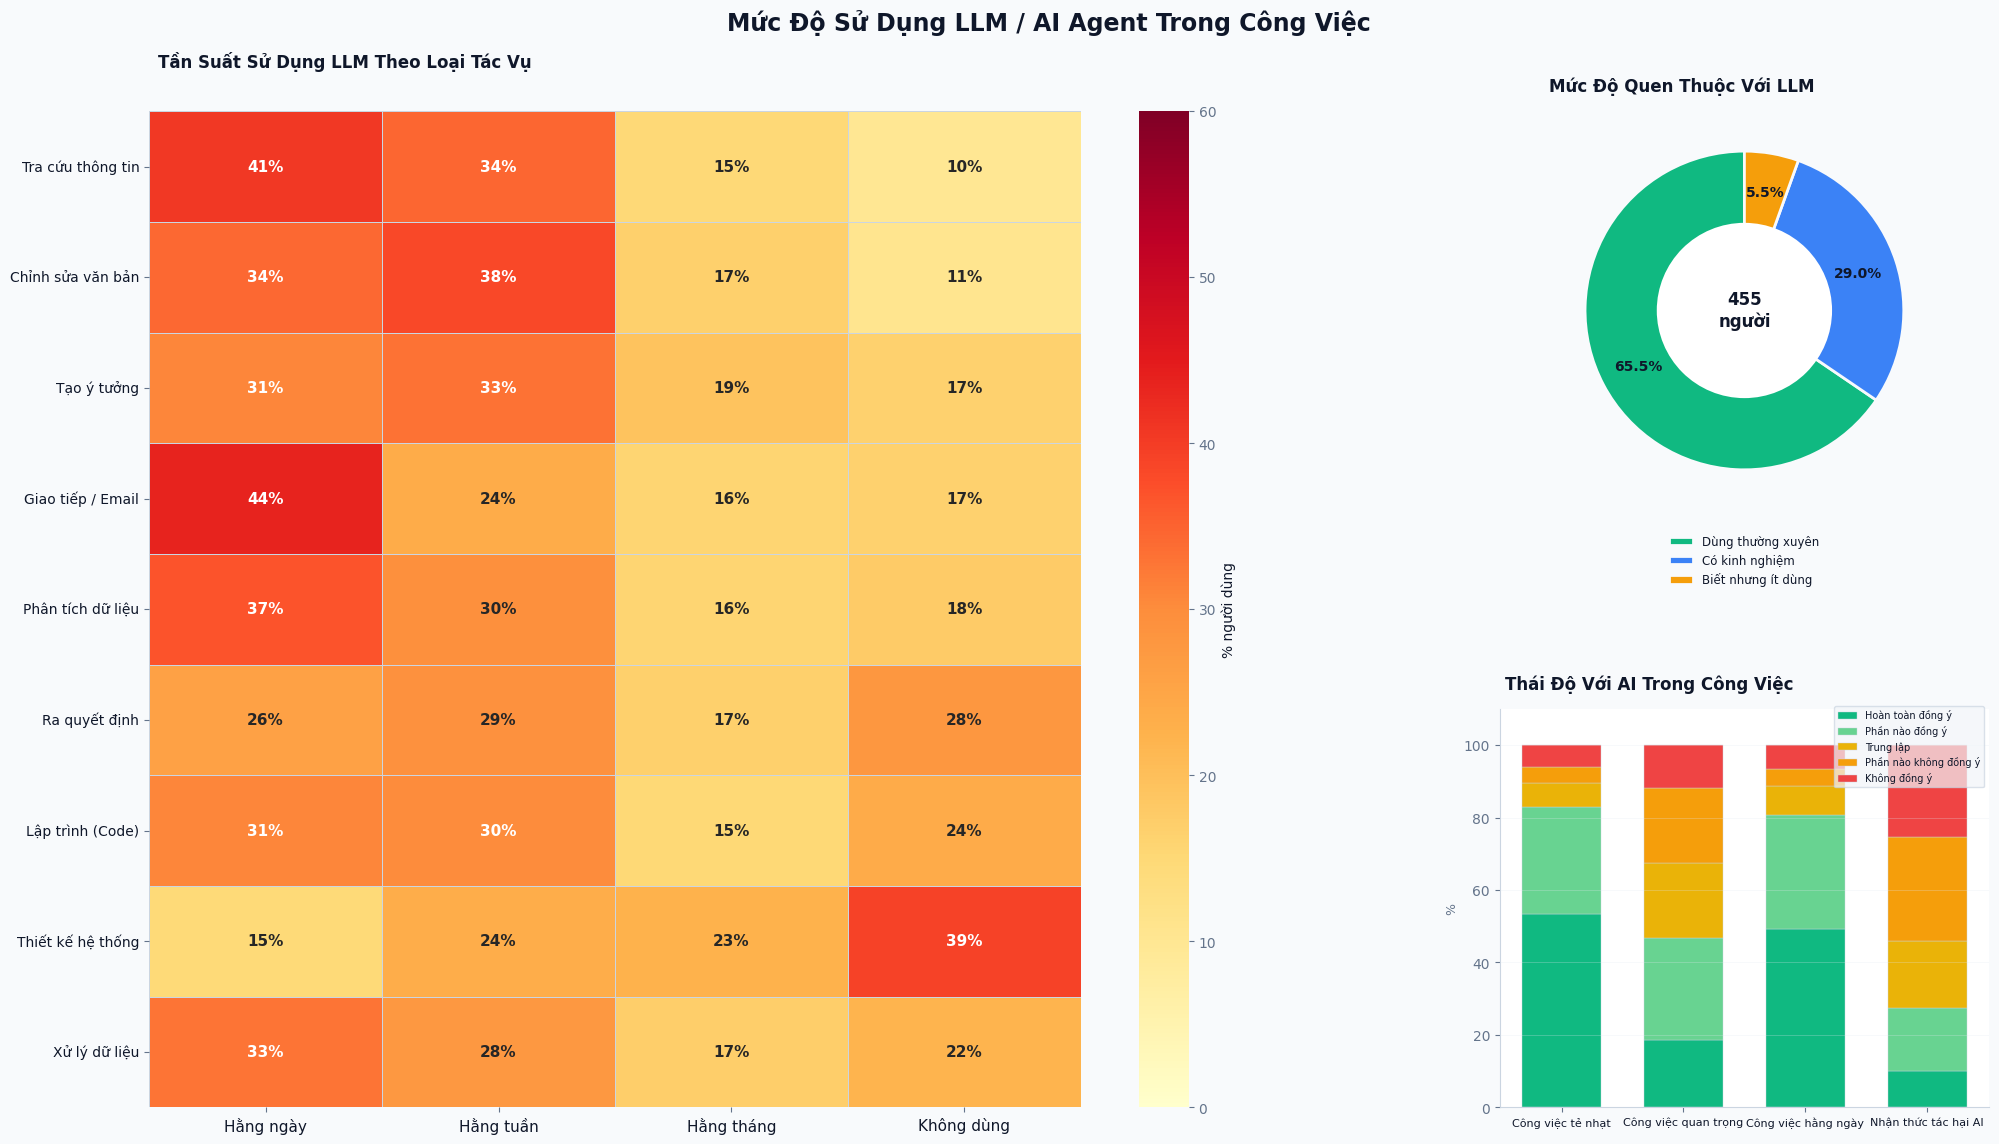

In [10]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4: SỬ DỤNG LLM TRONG CÔNG VIỆC CNTT
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 4 …")

llm_type_cols = {
    "Tra cứu thông tin": "LLM Usage by Type - Information Access",
    "Chỉnh sửa văn bản": "LLM Usage by Type - Edit",
    "Tạo ý tưởng":       "LLM Usage by Type - Idea Generation",
    "Giao tiếp / Email":  "LLM Usage by Type - Communication",
    "Phân tích dữ liệu": "LLM Usage by Type - Analysis",
    "Ra quyết định":     "LLM Usage by Type - Decision",
    "Lập trình (Code)":  "LLM Usage by Type - Coding",
    "Thiết kế hệ thống": "LLM Usage by Type - System Design",
    "Xử lý dữ liệu":    "LLM Usage by Type - Data Processing",
}
FREQ_ORDER = ["Daily", "Weekly", "Monthly", "Never"]
freq_labels_vi = {"Daily": "Hằng ngày", "Weekly": "Hằng tuần",
                  "Monthly": "Hằng tháng", "Never": "Không dùng"}

heat_data = []
for vi_label, col in llm_type_cols.items():
    row = {}
    for freq in FREQ_ORDER:
        row[freq] = (cs_meta[col] == freq).sum()
    heat_data.append(row)
heat_df = pd.DataFrame(heat_data, index=list(llm_type_cols.keys()))
heat_pct = heat_df.div(heat_df.sum(axis=1), axis=0) * 100
heat_pct.columns = [freq_labels_vi[f] for f in FREQ_ORDER]

fig4 = plt.figure(figsize=(20, 12), facecolor=BG)
fig_suptitle(fig4,
    "Mức Độ Sử Dụng LLM / AI Agent Trong Công Việc")
gs4 = GridSpec(2, 3, figure=fig4, hspace=0.5, wspace=0.38,
               left=0.05, right=0.97, top=0.90, bottom=0.07)

# 4-A  Heatmap LLM by Type
ax4a = fig4.add_subplot(gs4[:, :2])
mask_zero = heat_pct == 0
annot = heat_pct.map(lambda v: f"{v:.0f}%" if v > 0 else "")
sns.heatmap(heat_pct, ax=ax4a, cmap="YlOrRd",
            annot=annot, fmt="",
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=0.5, linecolor=BORDER,
            cbar_kws={"label": "% người dùng"},
            vmin=0, vmax=60)
ax4a.set_xticklabels(ax4a.get_xticklabels(), fontsize=11, color=TEXT)
ax4a.set_yticklabels(ax4a.get_yticklabels(), fontsize=10, color=TEXT, rotation=0)
ax4a.set_facecolor(PANEL)
title_box(ax4a, fig4,
    "Tần Suất Sử Dụng LLM Theo Loại Tác Vụ ")
# 4-B  Familiarity donut
ax4b = fig4.add_subplot(gs4[0, 2])
fam_counts = cs_meta["LLM Familiarity"].value_counts()
fam_labels = {
    "I use them regularly.": "Dùng thường xuyên",
    "I have some experience using them.": "Có kinh nghiệm",
    "I have heard of them but don't know much about their functionalities.": "Biết nhưng ít dùng",
    "I've never heard of them.": "Chưa biết",
}
labels_fam  = [fam_labels.get(k, k) for k in fam_counts.index]
wedge_colors = [GREEN, BLUE, ORANGE, RED][:len(fam_counts)]
wedges, texts, autotexts = ax4b.pie(
    fam_counts.values, labels=None, autopct="%1.1f%%",
    colors=wedge_colors, startangle=90,
    wedgeprops={"edgecolor": BG, "linewidth": 2},
    pctdistance=0.75)
for at in autotexts:
    at.set(fontsize=10, fontweight="bold", color=TEXT)

centre_circle = plt.Circle((0, 0), 0.55, fc=PANEL)
ax4b.add_artist(centre_circle)
ax4b.text(0, 0, f"{len(cs_meta)}\nngười", ha="center", va="center",
          fontsize=12, fontweight="bold", color=TEXT)
ax4b.legend(labels_fam, loc="lower center", bbox_to_anchor=(0.5, -0.22),
            fontsize=8.5, framealpha=0, labelcolor=TEXT, ncol=1)
ax4b.set_facecolor(PANEL)
title_box(ax4b, fig4, "Mức Độ Quen Thuộc Với LLM")
# 4-C  AI Attitude stacked bar
ax4c = fig4.add_subplot(gs4[1, 2])
attitude_cols_map = {
    "Công việc tẻ nhạt": "AI Tedious Work Attitude",
    "Công việc quan trọng": "AI Job Importance Attitude",
    "Công việc hằng ngày": "AI Daily Interest Attitude",
    "Nhận thức tác hại AI": "AI Suffering Attitude",
}
attit_order = ["Strongly agree", "Somewhat agree", "Neither agree nor disagree",
               "Somewhat disagree", "Strongly disagree"]
attit_vi    = {"Strongly agree": "Hoàn toàn đồng ý",
               "Somewhat agree": "Phần nào đồng ý",
               "Neither agree nor disagree": "Trung lập",
               "Somewhat disagree": "Phần nào không đồng ý",
               "Strongly disagree": "Không đồng ý"}
attit_colors = [GREEN, "#68D391", YELLOW, ORANGE, RED]

attit_data = {}
for lbl, col in attitude_cols_map.items():
    cnt = cs_meta[col].value_counts().reindex(attit_order, fill_value=0)
    attit_data[lbl] = (cnt / cnt.sum() * 100).values

x_att = np.arange(len(attitude_cols_map))
bottom = np.zeros(len(attitude_cols_map))
for j, (sentiment, color) in enumerate(zip(attit_order, attit_colors)):
    vals_att = [attit_data[k][j] for k in attitude_cols_map.keys()]
    ax4c.bar(x_att, vals_att, bottom=bottom, color=color,
             width=0.65, label=attit_vi[sentiment], edgecolor=BORDER, linewidth=0.3)
    bottom += np.array(vals_att)
ax4c.set_xticks(x_att)
ax4c.set_xticklabels(list(attitude_cols_map.keys()), fontsize=8, color=TEXT)
ax4c.set_ylabel("%", fontsize=9, color=SUBTEXT)
ax4c.set_ylim(0, 110)
ax4c.legend(fontsize=7, loc="upper right", framealpha=0.7,
            bbox_to_anchor=(1.0, 1.02))
ax4c.spines[["top","right"]].set_visible(False)
ax4c.grid(axis="y", alpha=0.3)
ax4c.set_facecolor(PANEL)
title_box(ax4c, fig4, "Thái Độ Với AI Trong Công Việc")
fig4.savefig("fig4_llm_usage.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 4 saved")
plt.show(fig4)




Rendering Figure 5 …
  ✓ Fig 5 saved


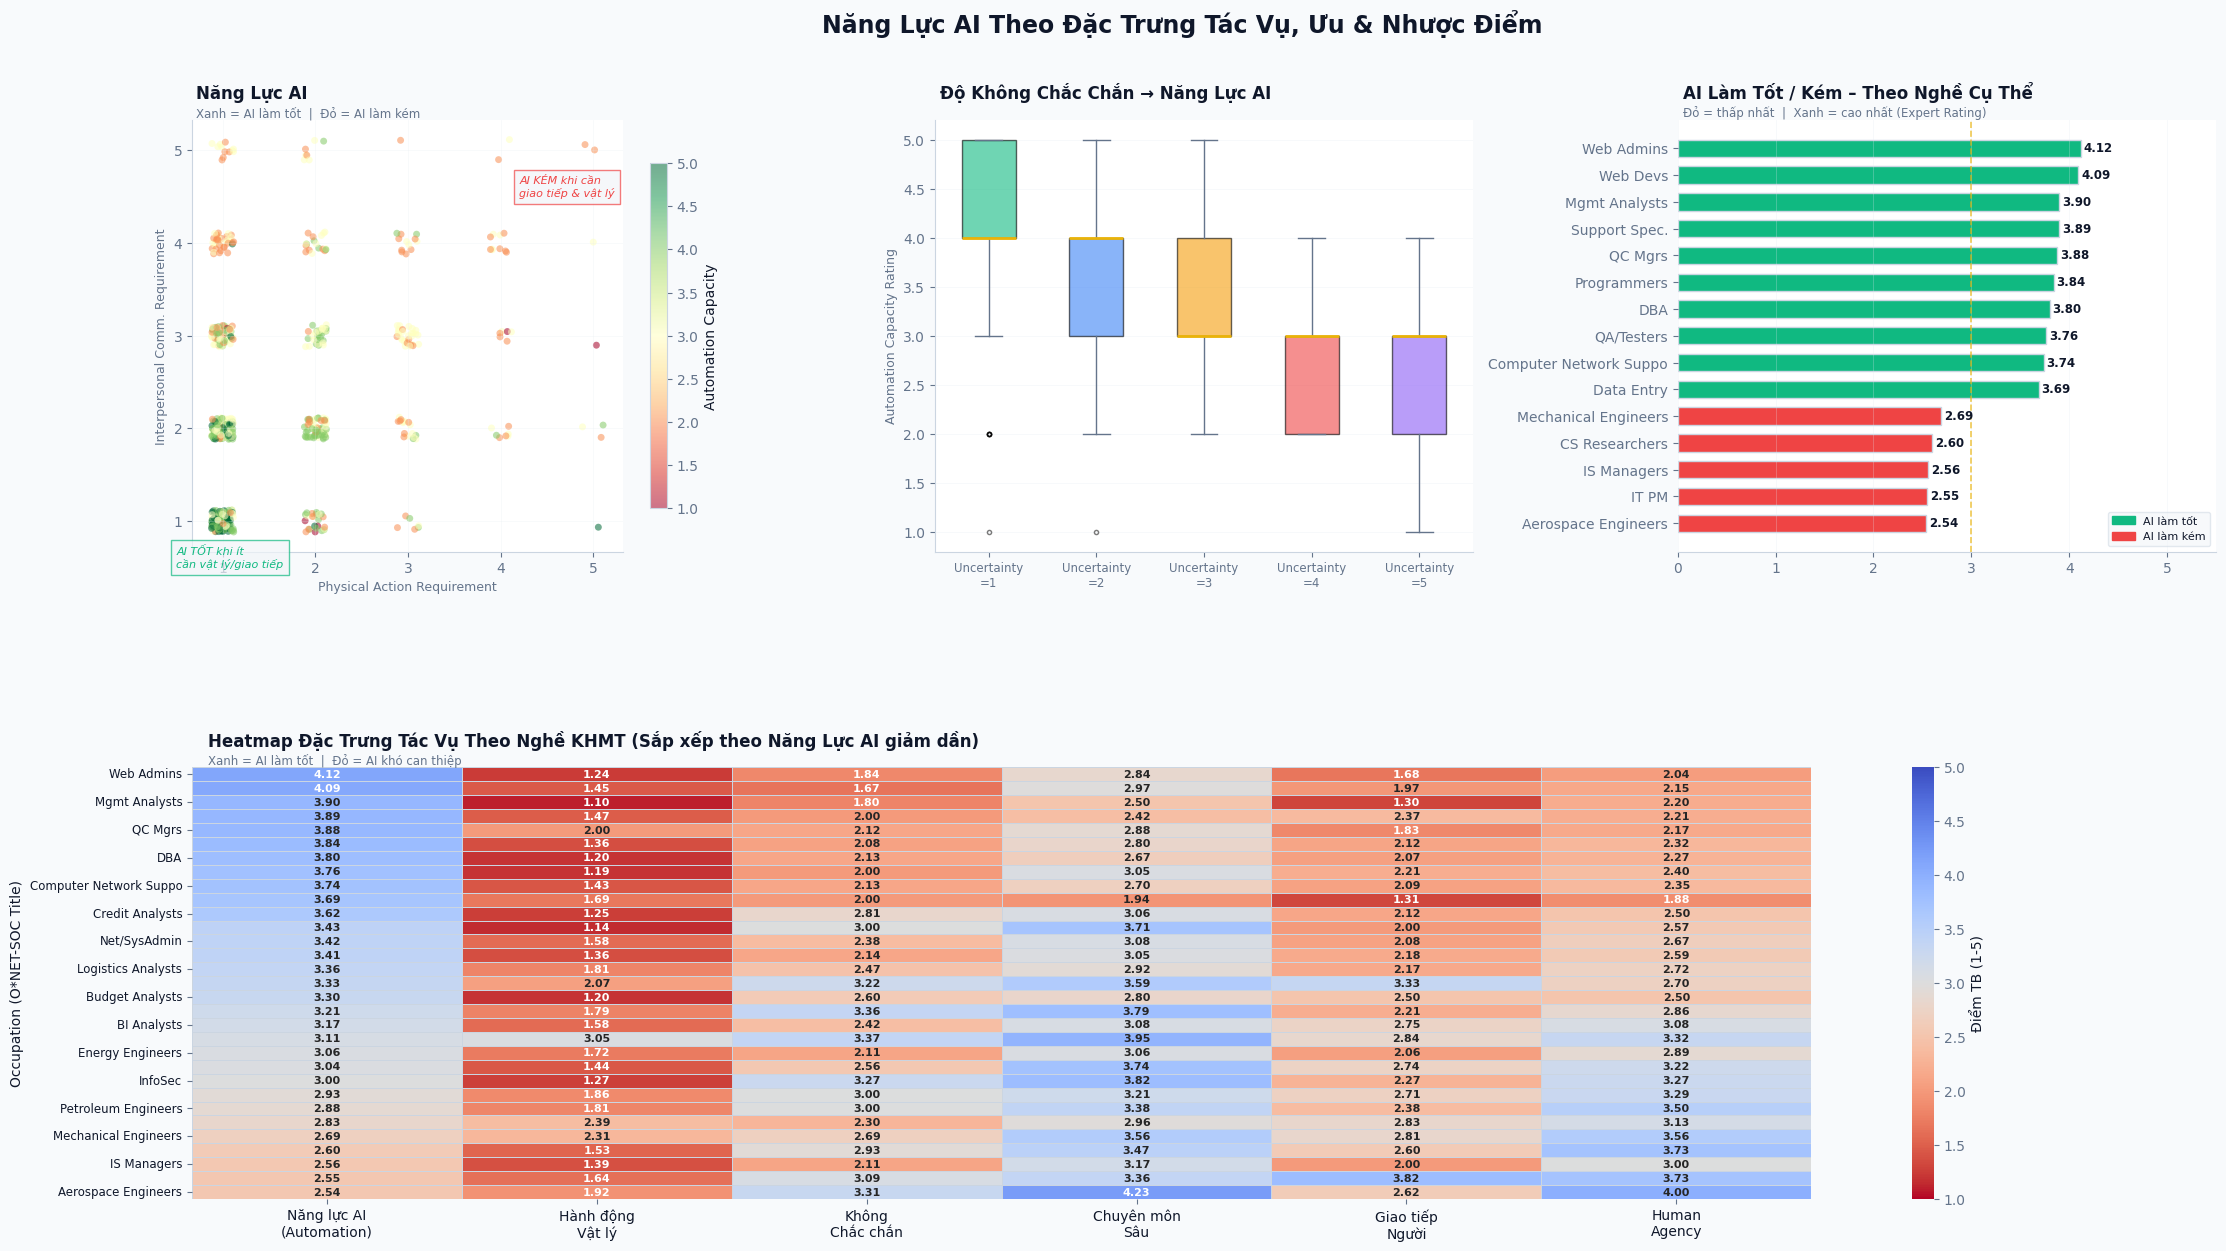

In [11]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5: NĂNG LỰC AI THEO ĐẶC TRƯNG TÁC VỤ
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 5 …")

# Merge expert + task metadata
exp_task = cs_expert.merge(
    cs_tasks[["Task ID", "Occupation (O*NET-SOC Title)",
              "Frequency", "Importance", "Relevance",
              "Occupation Mean Annual Wage"]],
    on=["Task ID", "Occupation (O*NET-SOC Title)"], how="left"
)

# Automation level bins for expert
exp_task["auto_lvl"] = pd.cut(exp_task["Automation Capacity Rating"],
                               bins=[0, 2, 3, 5],
                               labels=["Khó tự động\n(1-2)", "Trung bình\n(3)",
                                       "Dễ tự động\n(4-5)"])

fig5 = plt.figure(figsize=(22, 13), facecolor=BG)
fig_suptitle(fig5,
    "Năng Lực AI Theo Đặc Trưng Tác Vụ, Ưu & Nhược Điểm")
gs5 = GridSpec(2, 3, figure=fig5, hspace=0.5, wspace=0.38,
               left=0.05, right=0.97, top=0.90, bottom=0.07)

# 5-A  Scatter: Physical × Interpersonal → Automation Capacity
ax5a = fig5.add_subplot(gs5[0, 0])
jitter = 0.12
xs = cs_expert["Physical Action Requirement"] + np.random.uniform(-jitter, jitter, len(cs_expert))
ys = cs_expert["Interpersonal Communication Requirement"] + np.random.uniform(-jitter, jitter, len(cs_expert))
sc5a = ax5a.scatter(xs, ys, c=cs_expert["Automation Capacity Rating"],
                    cmap="RdYlGn", vmin=1, vmax=5,
                    s=25, alpha=0.55, edgecolors="none")
plt.colorbar(sc5a, ax=ax5a, label="Automation Capacity", shrink=0.8)
ax5a.set_xlabel("Physical Action Requirement", fontsize=9, color=SUBTEXT)
ax5a.set_ylabel("Interpersonal Comm. Requirement", fontsize=9, color=SUBTEXT)
ax5a.set_facecolor(PANEL)
ax5a.spines[["top","right"]].set_visible(False)
ax5a.grid(alpha=0.25)
title_box(ax5a, fig5,
    "Năng Lực AI",
    "Xanh = AI làm tốt  |  Đỏ = AI làm kém")
note5a = "AI KÉM khi cần\ngiao tiếp & vật lý"
ax5a.text(4.2, 4.5, note5a, fontsize=8, color=RED,
          fontstyle="italic", bbox=dict(facecolor=PANEL2, edgecolor=RED, alpha=0.7))
note5b = "AI TỐT khi ít\ncần vật lý/giao tiếp"
ax5a.text(0.5, 0.5, note5b, fontsize=8, color=GREEN,
          fontstyle="italic", bbox=dict(facecolor=PANEL2, edgecolor=GREEN, alpha=0.7))

# 5-B  Box: Automation by Uncertainty & Domain Expertise
ax5b = fig5.add_subplot(gs5[0, 1])
pivot_unc = cs_expert.groupby("Involved Uncertainty")["Automation Capacity Rating"].agg(list)
labels_unc = [f"Uncertainty\n={v}" for v in sorted(pivot_unc.index)]
data_unc   = [pivot_unc[v] for v in sorted(pivot_unc.index)]
bp = ax5b.boxplot(data_unc, patch_artist=True, vert=True,
                  medianprops={"color": YELLOW, "linewidth": 2},
                  whiskerprops={"color": SUBTEXT},
                  capprops={"color": SUBTEXT},
                  flierprops={"marker": "o", "color": SUBTEXT,
                              "alpha": 0.3, "markersize": 3})
for patch, color in zip(bp["boxes"], [GREEN, BLUE, ORANGE, RED, PURPLE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax5b.set_xticklabels(labels_unc, fontsize=8.5)
ax5b.set_ylabel("Automation Capacity Rating", fontsize=9, color=SUBTEXT)
ax5b.set_facecolor(PANEL)
ax5b.spines[["top","right"]].set_visible(False)
ax5b.grid(axis="y", alpha=0.3)
title_box(ax5b, fig5,
    "Độ Không Chắc Chắn → Năng Lực AI")
# 5-C  Avg capacity per CS occupation (top 12 + bottom 5)
ax5c = fig5.add_subplot(gs5[0, 2])
occ_cap = (cs_expert.groupby("Occupation (O*NET-SOC Title)")["Automation Capacity Rating"]
           .mean().sort_values())
top_bot = pd.concat([occ_cap.head(5), occ_cap.tail(10)])
bar_colors = [RED]*5 + [GREEN]*10
bars_c = ax5c.barh([shorten(o) for o in top_bot.index],
                   top_bot.values,
                   color=bar_colors, height=0.65, edgecolor=BORDER)
for bar, v in zip(bars_c, top_bot.values):
    ax5c.text(v + 0.03, bar.get_y() + bar.get_height()/2,
              f"{v:.2f}", va="center", fontsize=8.5, color=TEXT,
              fontweight="bold")
ax5c.axvline(3, color=YELLOW, lw=1.2, ls="--", alpha=0.7)
ax5c.set_xlim(0, 5.5)
ax5c.spines[["top","right","left"]].set_visible(False)
ax5c.grid(axis="x", alpha=0.3)
ax5c.set_facecolor(PANEL)
red_p = mpatches.Patch(color=RED, label="AI làm kém")
grn_p = mpatches.Patch(color=GREEN, label="AI làm tốt")
ax5c.legend(handles=[grn_p, red_p], fontsize=8, framealpha=0.5)
title_box(ax5c, fig5,
    "AI Làm Tốt / Kém – Theo Nghề Cụ Thể",
    "Đỏ = thấp nhất  |  Xanh = cao nhất (Expert Rating)")

# 5-D  Heatmap: Occupation × Task Characteristic
ax5d = fig5.add_subplot(gs5[1, :])
heat_cols = ["Automation Capacity Rating", "Physical Action Requirement",
             "Involved Uncertainty", "Domain Expertise Requirement",
             "Interpersonal Communication Requirement", "Human Agency Scale Rating"]
heat_occ = (cs_expert.groupby("Occupation (O*NET-SOC Title)")[heat_cols]
            .mean()
            .rename(index=shorten))
heat_occ = heat_occ.sort_values("Automation Capacity Rating", ascending=False)
heat_occ.columns = ["Năng lực AI\n(Automation)", "Hành động\nVật lý",
                    "Không\nChắc chắn", "Chuyên môn\nSâu", "Giao tiếp\nNgười",
                    "Human\nAgency"]
sns.heatmap(heat_occ, ax=ax5d, cmap="coolwarm_r",
            annot=True, fmt=".2f",
            annot_kws={"size": 8, "weight": "bold"},
            linewidths=0.4, linecolor=BORDER,
            cbar_kws={"label": "Điểm TB (1-5)"},
            vmin=1, vmax=5)
ax5d.set_xticklabels(ax5d.get_xticklabels(), fontsize=10, color=TEXT)
ax5d.set_yticklabels(ax5d.get_yticklabels(), fontsize=8.5, color=TEXT, rotation=0)
ax5d.set_facecolor(PANEL)
title_box(ax5d, fig5,
    "Heatmap Đặc Trưng Tác Vụ Theo Nghề KHMT (Sắp xếp theo Năng Lực AI giảm dần)",
    "Xanh = AI làm tốt  |  Đỏ = AI khó can thiệp")

fig5.savefig("fig5_task_capability.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 5 saved")
plt.show(fig5)




Rendering Figure 6 …
  ✓ Fig 6 saved


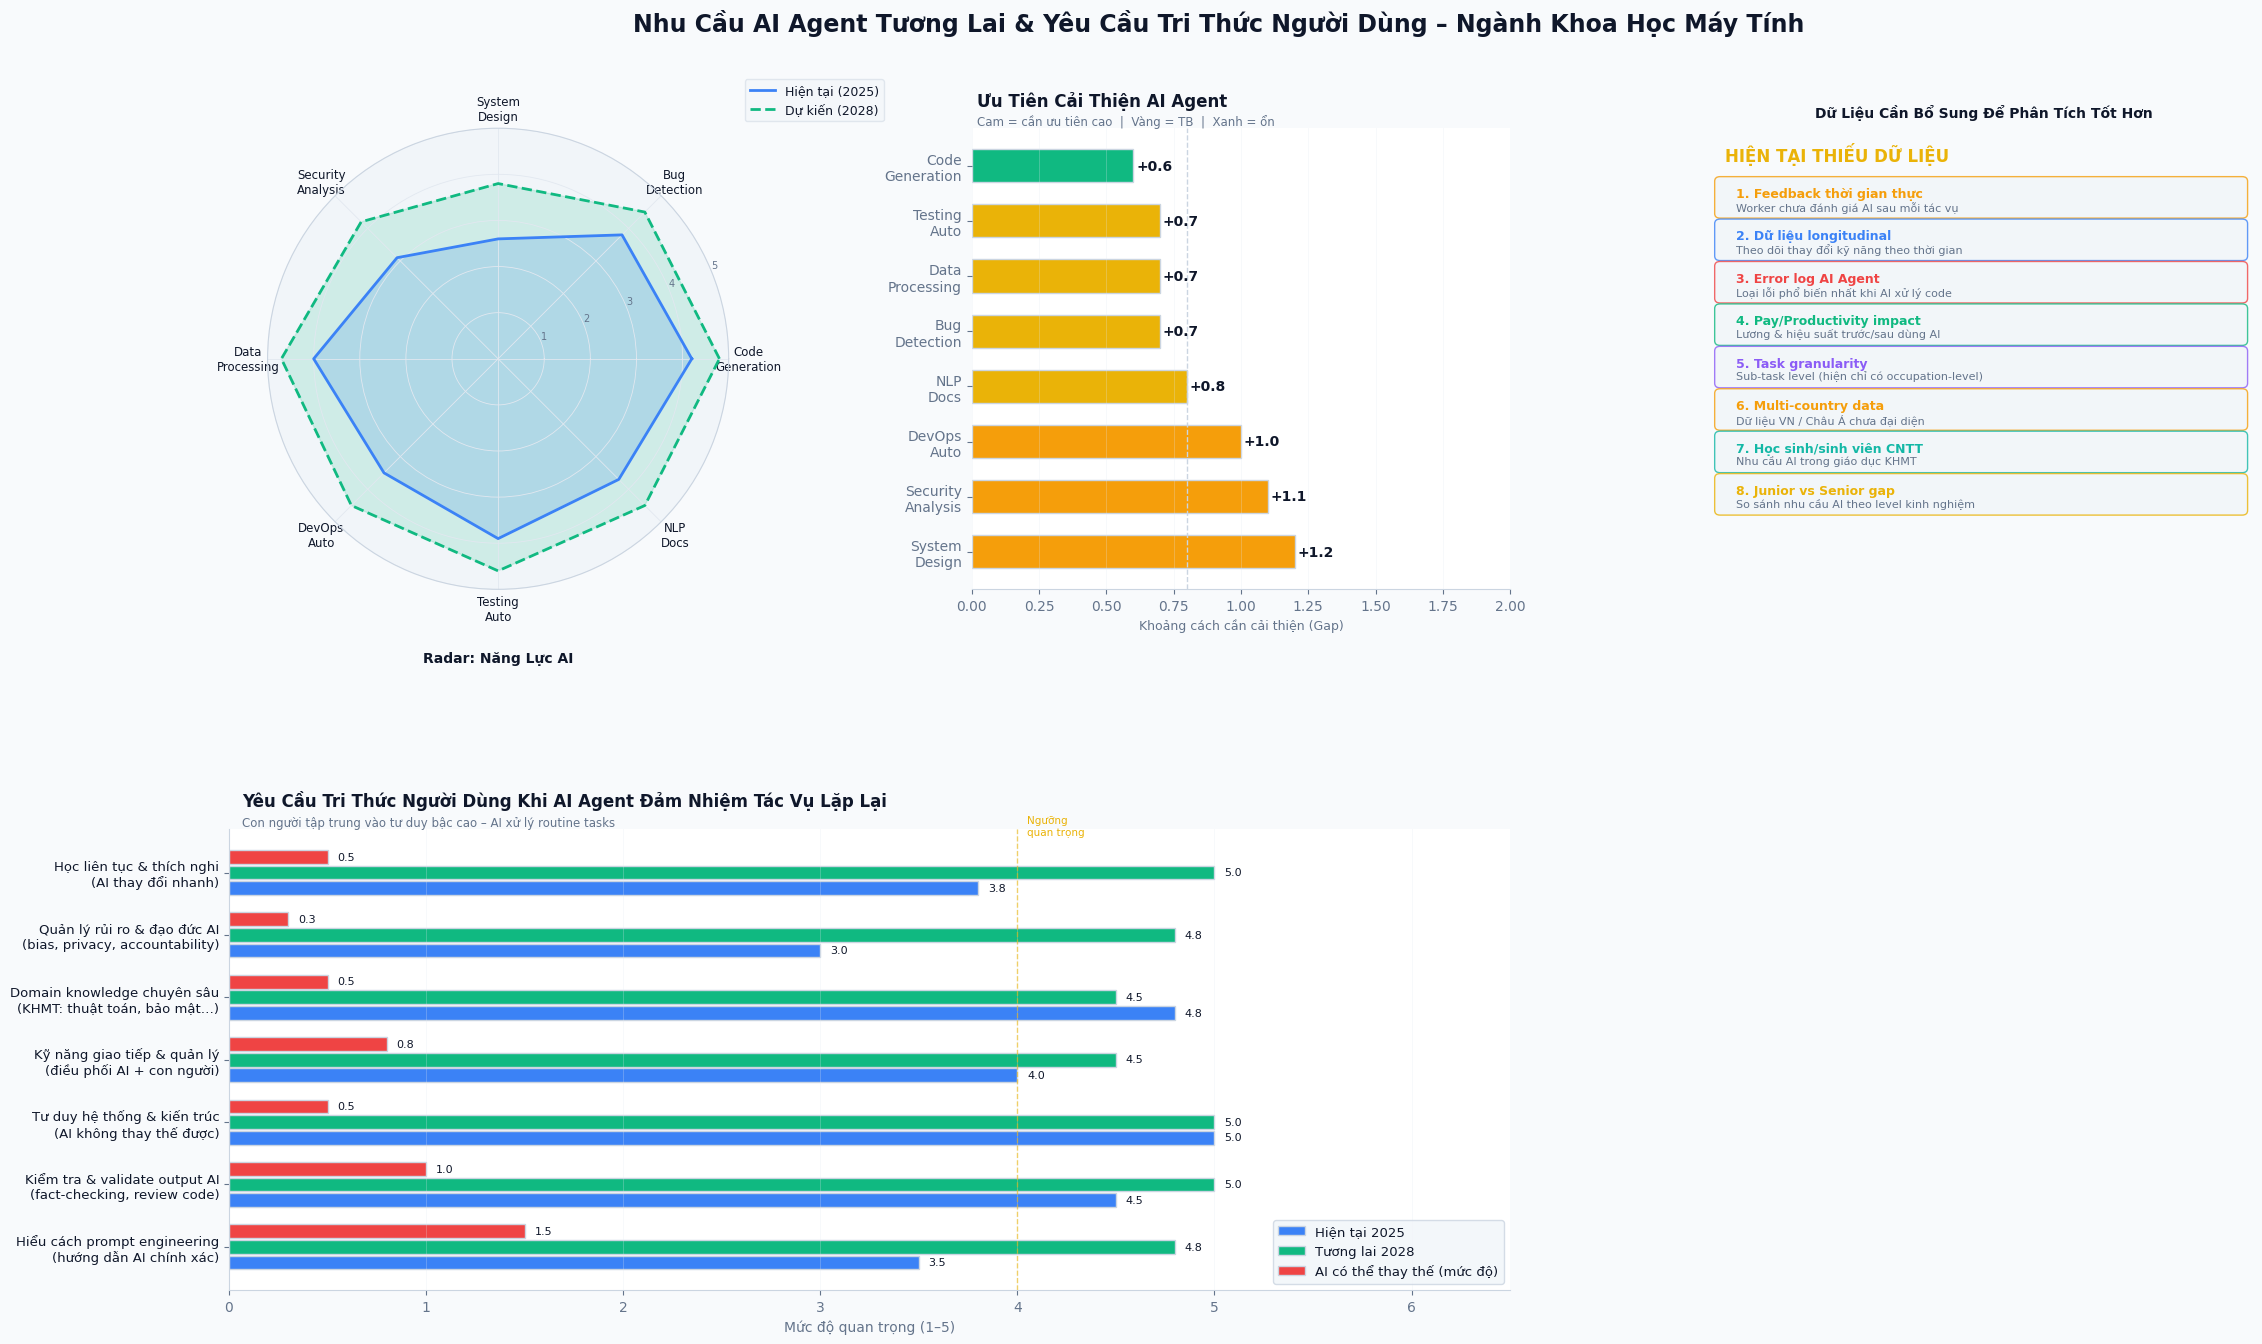

In [16]:
# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 6: NHU CẦU TƯƠNG LAI & YÊU CẦU TRI THỨC NGƯỜI DÙNG
# ═════════════════════════════════════════════════════════════════════════════
print("Rendering Figure 6 …")

fig6 = plt.figure(figsize=(22, 14), facecolor=BG)
fig_suptitle(fig6,
    "Nhu Cầu AI Agent Tương Lai & Yêu Cầu Tri Thức Người Dùng – Ngành Khoa Học Máy Tính")
gs6 = GridSpec(2, 3, figure=fig6, hspace=0.52, wspace=0.38,
               left=0.05, right=0.97, top=0.90, bottom=0.07)

# 6-A  Radar: Current vs Future AI needs
ax6a = fig6.add_subplot(gs6[0, 0], polar=True)
radar_cats = ["Code\nGeneration", "Bug\nDetection", "System\nDesign", "Security\nAnalysis",
              "Data\nProcessing", "DevOps\nAuto", "Testing\nAuto", "NLP\nDocs"]
N = len(radar_cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Current (from expert data approximation)
current_vals = [4.2, 3.8, 2.6, 3.1, 4.0, 3.5, 3.9, 3.7]
# Future expected (2027-2030 projection)
future_vals  = [4.8, 4.5, 3.8, 4.2, 4.7, 4.5, 4.6, 4.5]
current_vals += current_vals[:1]
future_vals  += future_vals[:1]

ax6a.plot(angles, current_vals, color=BLUE, lw=2, label="Hiện tại (2025)")
ax6a.fill(angles, current_vals, color=BLUE, alpha=0.2)
ax6a.plot(angles, future_vals, color=GREEN, lw=2, ls="--", label="Dự kiến (2028)")
ax6a.fill(angles, future_vals, color=GREEN, alpha=0.15)
ax6a.set_xticks(angles[:-1])
ax6a.set_xticklabels(radar_cats, size=8.5, color=TEXT)
ax6a.set_ylim(0, 5)
ax6a.set_yticks([1, 2, 3, 4, 5])
ax6a.set_yticklabels(["1", "2", "3", "4", "5"], size=7, color=SUBTEXT)
ax6a.set_facecolor(PANEL2)
ax6a.spines["polar"].set_color(BORDER)
ax6a.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12),
            fontsize=9, framealpha=0.5)
# Thêm tiêu đề phía dưới radar
ax6a.text(
    0.5, -0.15,
    "Radar: Năng Lực AI",
    transform=ax6a.transAxes,
    ha="center",
    va="center",
    color=TEXT,
    fontsize=10,
    fontweight="bold"
)

# 6-B  Gap bar: what AI needs to improve
ax6b = fig6.add_subplot(gs6[0, 1])
gaps = {cat: f - c for cat, f, c in
        zip(radar_cats, future_vals[:-1], current_vals[:-1])}
gaps_sorted = dict(sorted(gaps.items(), key=lambda x: x[1], reverse=True))
gap_colors = [ORANGE if v >= 1.0 else YELLOW if v >= 0.6 else GREEN
              for v in gaps_sorted.values()]
bars_gap = ax6b.barh(list(gaps_sorted.keys()), list(gaps_sorted.values()),
                     color=gap_colors, height=0.6, edgecolor=BORDER)
for bar, v in zip(bars_gap, gaps_sorted.values()):
    ax6b.text(v + 0.01, bar.get_y() + bar.get_height()/2,
              f"+{v:.1f}", va="center", fontsize=10,
              color=TEXT, fontweight="bold")
ax6b.set_xlim(0, 2.0)
ax6b.axvline(0.8, color=BORDER, lw=1, ls="--")
ax6b.spines[["top","right","left"]].set_visible(False)
ax6b.grid(axis="x", alpha=0.3)
ax6b.set_facecolor(PANEL)
ax6b.set_xlabel("Khoảng cách cần cải thiện (Gap)", fontsize=9, color=SUBTEXT)
title_box(ax6b, fig6,
    "Ưu Tiên Cải Thiện AI Agent",
    "Cam = cần ưu tiên cao  |  Vàng = TB  |  Xanh = ổn")

# 6-C  Data gaps: What data needs to be collected
ax6c = fig6.add_subplot(gs6[0, 2])
ax6c.set_facecolor(PANEL)
ax6c.axis("off")
data_gaps = [
    ("HIỆN TẠI THIẾU DỮ LIỆU", "", YELLOW),
    ("", "", ""),
    ("1. Feedback thời gian thực", "Worker chưa đánh giá AI sau mỗi tác vụ", ORANGE),
    ("2. Dữ liệu longitudinal", "Theo dõi thay đổi kỹ năng theo thời gian", BLUE),
    ("3. Error log AI Agent", "Loại lỗi phổ biến nhất khi AI xử lý code", RED),
    ("4. Pay/Productivity impact", "Lương & hiệu suất trước/sau dùng AI", GREEN),
    ("5. Task granularity", "Sub-task level (hiện chỉ có occupation-level)", PURPLE),
    ("6. Multi-country data", "Dữ liệu VN / Châu Á chưa đại diện", ORANGE),
    ("7. Học sinh/sinh viên CNTT", "Nhu cầu AI trong giáo dục KHMT", TEAL),
    ("8. Junior vs Senior gap", "So sánh nhu cầu AI theo level kinh nghiệm", YELLOW),
]
y_pos = 0.97
for title_t, desc, color in data_gaps:
    if title_t == "":
        y_pos -= 0.03
        continue
    if desc == "":
        ax6c.text(0.02, y_pos, title_t, transform=ax6c.transAxes,
                  fontsize=12, fontweight="bold", color=color, va="top")
        y_pos -= 0.05
    else:
        ax6c.add_patch(FancyBboxPatch(
            (0.01, y_pos - 0.075), 0.97, 0.07,
            boxstyle="round,pad=0.01",
            facecolor=PANEL2, edgecolor=color,
            transform=ax6c.transAxes, clip_on=False, alpha=0.8))
        ax6c.text(0.04, y_pos - 0.018, title_t, transform=ax6c.transAxes,
                  fontsize=9, fontweight="bold", color=color, va="top")
        ax6c.text(0.04, y_pos - 0.048, desc, transform=ax6c.transAxes,
                  fontsize=8, color=SUBTEXT, va="top")
        y_pos -= 0.092
ax6c.set_title("Dữ Liệu Cần Bổ Sung Để Phân Tích Tốt Hơn",
               color=TEXT, fontsize=10, fontweight="bold", pad=8)

# 6-D  User Knowledge Requirements (stacked horizontal bar)
ax6d = fig6.add_subplot(gs6[1, :2])
knowledge_areas = [
    "Hiểu cách prompt engineering\n(hướng dẫn AI chính xác)",
    "Kiểm tra & validate output AI\n(fact-checking, review code)",
    "Tư duy hệ thống & kiến trúc\n(AI không thay thế được)",
    "Kỹ năng giao tiếp & quản lý\n(điều phối AI + con người)",
    "Domain knowledge chuyên sâu\n(KHMT: thuật toán, bảo mật…)",
    "Quản lý rủi ro & đạo đức AI\n(bias, privacy, accountability)",
    "Học liên tục & thích nghi\n(AI thay đổi nhanh)",
]
importance_now  = [3.5, 4.5, 5.0, 4.0, 4.8, 3.0, 3.8]
importance_2028 = [4.8, 5.0, 5.0, 4.5, 4.5, 4.8, 5.0]
ai_can_replace  = [1.5, 1.0, 0.5, 0.8, 0.5, 0.3, 0.5]

y_pos_d = np.arange(len(knowledge_areas))
bars_now  = ax6d.barh(y_pos_d - 0.25, importance_now,  height=0.22,
                       color=BLUE, label="Hiện tại 2025", edgecolor=BORDER)
bars_28   = ax6d.barh(y_pos_d,        importance_2028, height=0.22,
                       color=GREEN, label="Tương lai 2028", edgecolor=BORDER)
bars_ai   = ax6d.barh(y_pos_d + 0.25, ai_can_replace,  height=0.22,
                       color=RED, label="AI có thể thay thế (mức độ)", edgecolor=BORDER)

for bars in [bars_now, bars_28, bars_ai]:
    for bar in bars:
        w = bar.get_width()
        ax6d.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                  f"{w:.1f}", va="center", fontsize=8, color=TEXT)
ax6d.set_yticks(y_pos_d)
ax6d.set_yticklabels(knowledge_areas, fontsize=9.5, color=TEXT)
ax6d.set_xlim(0, 6.5)
ax6d.axvline(4.0, color=YELLOW, lw=1, ls="--", alpha=0.6)
ax6d.text(4.05, len(knowledge_areas) - 0.4, "Ngưỡng\nquan trọng",
          fontsize=7.5, color=YELLOW)
ax6d.legend(fontsize=9.5, loc="lower right")
ax6d.spines[["top","right"]].set_visible(False)
ax6d.grid(axis="x", alpha=0.3)
ax6d.set_facecolor(PANEL)
ax6d.set_xlabel("Mức độ quan trọng (1–5)", fontsize=10, color=SUBTEXT)
title_box(ax6d, fig6,
    "Yêu Cầu Tri Thức Người Dùng Khi AI Agent Đảm Nhiệm Tác Vụ Lặp Lại",
    "Con người tập trung vào tư duy bậc cao – AI xử lý routine tasks")


fig6.savefig("fig6_future_needs.png",
             dpi=160, bbox_inches="tight", facecolor=BG)
print("  ✓ Fig 6 saved")
plt.show(fig6)

